# MLP feature experiment

Reads `keypoints.npz` from `extract_keypoints.ipynb`. Set `FEATURES` in the
vector cell, run top to bottom, and the test cell writes `runs/<mode>.npz`
for `experiments.ipynb`.

In [26]:
from pathlib import Path

import numpy as np

KEYPOINTS = Path("keypoints.npz")   # written by extract_keypoints.ipynb

_z = np.load(KEYPOINTS)
CLASSES = [str(c) for c in _z["classes"]]
train_kp, train_world = _z["train_kp"], _z["train_world"]
train_presence, train_handed, train_labels = (
    _z["train_presence"], _z["train_handed"], _z["train_labels"])
train_deg = _z["train_deg"]
val_kp, val_world = _z["val_kp"], _z["val_world"]
val_presence, val_handed, val_labels = (
    _z["val_presence"], _z["val_handed"], _z["val_labels"])
val_deg = _z["val_deg"]
test_kp, test_world = _z["test_kp"], _z["test_world"]
test_presence, test_handed, test_labels, test_left = (
    _z["test_presence"], _z["test_handed"], _z["test_labels"], _z["test_left"])
test_deg = _z["test_deg"]
test_labelled, test_detected = int(_z["test_labelled"]), int(_z["test_detected"])

print(f"train {train_kp.shape}  val {val_kp.shape}  test {test_kp.shape}")
print(f"{len(CLASSES)} classes   "
      f"{test_labelled:,} test images labelled -> {test_detected:,} past the palm gate")

train (287851, 21, 3)  val (71950, 21, 3)  test (6526, 21, 3)
26 classes   6,576 test images labelled -> 6,526 past the palm gate


In [27]:
# --- Pose jitter, training rows only ----------------------------------------------
# Every training crop arrives straightened and shot head-on, so the model never sees a
# letter a few degrees off its usual pose and folds "arrives the usual way" into the
# letter's identity. Jittered copies break that.
#
# The rotation is applied to the world landmarks about the wrist, and the pixel
# keypoints are re-projected from them with each row's own scale (kp is a scaled copy
# of world, R^2 0.996 on x,y), so the image block keeps foreshortening consistent with
# the 3D one. deg is deliberately left alone: this models the palm detector estimating
# the angle imperfectly, and the angle it reported is the angle it reported.
# Only train grows -- jittering val or test would score the model on its own trick.
import numpy as np

JITTER = (10.0, 10.0, 10.0)   # +/- degrees about x (tilt), y (turn), z (in-plane spin)
COPIES = 1                    # jittered copies added per training row

_rng = np.random.default_rng(0)


def rotations(angles):
    """(N, 3) degrees about x, y, z -> (N, 3, 3), applied x then y then z."""
    c, s = np.cos(np.radians(angles)), np.sin(np.radians(angles))
    out = np.zeros((len(angles), 3, 3))
    out[:, 0, 0] = c[:, 1] * c[:, 2]
    out[:, 0, 1] = s[:, 0] * s[:, 1] * c[:, 2] - c[:, 0] * s[:, 2]
    out[:, 0, 2] = c[:, 0] * s[:, 1] * c[:, 2] + s[:, 0] * s[:, 2]
    out[:, 1, 0] = c[:, 1] * s[:, 2]
    out[:, 1, 1] = s[:, 0] * s[:, 1] * s[:, 2] + c[:, 0] * c[:, 2]
    out[:, 1, 2] = c[:, 0] * s[:, 1] * s[:, 2] - s[:, 0] * c[:, 2]
    out[:, 2, 0] = -s[:, 1]
    out[:, 2, 1] = s[:, 0] * c[:, 1]
    out[:, 2, 2] = c[:, 0] * c[:, 1]
    return out


def jitter(kp, world, angles):
    """Turn each hand about its wrist and re-project the pixel keypoints to match."""
    w = world - world[:, :1, :]
    turned = np.einsum("nij,nkj->nki", rotations(angles), w)
    k = kp - kp[:, :1, :]
    scale = lambda a, b: ((a * b).sum((1, 2)) / np.maximum((b * b).sum((1, 2)), 1e-12))
    s_xy, s_z = scale(k[..., :2], w[..., :2])[:, None], scale(k[..., 2:], w[..., 2:])[:, None]
    out = np.empty_like(kp)
    out[..., :2] = kp[:, :1, :2] + s_xy[..., None] * turned[..., :2]
    out[..., 2] = kp[:, :1, 2] + s_z * turned[..., 2]
    return out, turned + world[:, :1, :]


# Re-runnable: the originals are kept so the set does not double on every execution.
if "_RAW_TRAIN" not in globals():
    _RAW_TRAIN = (train_kp, train_world, train_presence, train_handed,
                  train_labels, train_deg)
train_kp, train_world, train_presence, train_handed, train_labels, train_deg = _RAW_TRAIN

_kp, _world = [train_kp], [train_world]
for _ in range(COPIES):
    _angles = _rng.uniform(-1.0, 1.0, (len(train_kp), 3)) * JITTER
    _k, _w = jitter(train_kp, train_world, _angles)
    _kp.append(_k)
    _world.append(_w)

train_kp, train_world = np.concatenate(_kp), np.concatenate(_world)
train_presence = np.tile(train_presence, COPIES + 1)
train_handed = np.tile(train_handed, COPIES + 1)
train_labels = np.tile(train_labels, COPIES + 1)
train_deg = np.tile(train_deg, COPIES + 1)

print(f"jitter +/-{JITTER[0]:.0f}/{JITTER[1]:.0f}/{JITTER[2]:.0f} deg about x/y/z, "
      f"{COPIES} extra cop{'y' if COPIES == 1 else 'ies'}")
print(f"train {len(_RAW_TRAIN[0]):,} -> {len(train_kp):,} rows   (val and test untouched)")

jitter +/-10/10/10 deg about x/y/z, 1 extra copy
train 287,851 -> 575,702 rows   (val and test untouched)


In [28]:
# --- Cached landmarks -> the model's input vector ---------------------------------
# Two gates, both the model's own opinion of its own output: presence says the crop
# held a hand, a handedness score near the middle says it could not tell left from
# right. Spans are measured over train and val together, one per block, so everything
# lands inside [0,1] without clipping. FEATURES picks which blocks are kept.
import numpy as np

LM_SIZE = 224
MIN_PRESENCE = 0.5
HANDED_BAND = (0.4, 0.6)

# "2d"      = image x,y only (42)
# "2.5d"    = image x,y + depth z (63)
# "3d"      = wrist-relative world landmarks (63)
# "2d+3d"   = 42 + 63 (105)
# "2.5d+3d" = 63 + 63 (126)   -- same meaning as config.FEATURES in the repo root
# "3d+dir"  = 63 + how far the hand was turned, as sin and cos (65)
FEATURES = "3d+dir"
FEATURE_DIMS = {"2d": 42, "2.5d": 63, "3d": 63, "2d+3d": 105, "2.5d+3d": 126,
                "3d+dir": 65}
IN_DIM = FEATURE_DIMS[FEATURES]


def mirror(kp, world, deg, handed):
    """Left hands folded onto right, so one sign is one shape. Only x moves.

    Flipping x left-to-right also turns the hand the other way, so deg flips sign.
    """
    flip = handed < 0.5
    kp, world, deg = kp.copy(), world.copy(), deg.copy()
    kp[flip, :, 0] = LM_SIZE - kp[flip, :, 0]
    world[flip, :, 0] *= -1.0
    deg[flip] *= -1.0
    return kp, world, deg


def keep_of(presence, handed):
    return (presence >= MIN_PRESENCE) & ((handed <= HANDED_BAND[0]) | (handed >= HANDED_BAND[1]))


train_keep, val_keep = keep_of(train_presence, train_handed), keep_of(val_presence, val_handed)
train_y, val_y = train_labels[train_keep], val_labels[val_keep]
tr_kp, tr_w, tr_deg = mirror(train_kp[train_keep], train_world[train_keep],
                             train_deg[train_keep], train_handed[train_keep])
va_kp, va_w, va_deg = mirror(val_kp[val_keep], val_world[val_keep],
                             val_deg[val_keep], val_handed[val_keep])
tr_w -= tr_w[:, :1, :]                      # node 0 is the wrist; offsets first,
va_w -= va_w[:, :1, :]                      # then one span over the offsets

span = lambda a, b: (min(a.min(), b.min()), max(a.max(), b.max()))
XY_SPAN = span(tr_kp[..., :2], va_kp[..., :2])
Z_SPAN = span(tr_kp[..., 2], va_kp[..., 2])
W_SPAN = span(tr_w, va_w)
unit = lambda a, s: (a - s[0]) / (s[1] - s[0])


def direction_of(deg):
    """The turn angle as two numbers in [0,1], so -179 and +179 stay neighbours."""
    radians = np.radians(deg)
    return np.stack([np.sin(radians), np.cos(radians)], 1) * 0.5 + 0.5


def features(kp, world, deg):
    """-> (N, IN_DIM) in [0,1]. Blocks match config.FEATURES in the repo root."""
    n = len(kp)
    xy = unit(kp[..., :2], XY_SPAN).reshape(n, -1)
    z = unit(kp[..., 2], Z_SPAN).reshape(n, -1)
    w = unit(world, W_SPAN).reshape(n, -1)
    if FEATURES == "2d":
        parts = [xy]
    elif FEATURES == "2.5d":
        parts = [xy, z]
    elif FEATURES == "3d":
        parts = [w]
    elif FEATURES == "2d+3d":
        parts = [xy, w]
    elif FEATURES == "2.5d+3d":
        parts = [xy, z, w]
    elif FEATURES == "3d+dir":
        parts = [w, direction_of(deg)]
    else:
        raise ValueError(f"FEATURES must be one of {tuple(FEATURE_DIMS)} (got {FEATURES!r})")
    return np.concatenate(parts, 1).astype(np.float32)


X_train, X_val = features(tr_kp, tr_w, tr_deg), features(va_kp, va_w, va_deg)
assert X_train.shape[1] == IN_DIM and X_train.min() >= 0 and X_train.max() <= 1

print(f"FEATURES {FEATURES!r} -> {IN_DIM} dims")
print(f"train {train_keep.sum():,}/{len(train_keep):,} kept   "
      f"val {val_keep.sum():,}/{len(val_keep):,} kept")
print(f"mirrored {np.mean(train_handed[train_keep] < 0.5):.1%} of train (the left hands)")
if FEATURES not in ("3d", "3d+dir"):
    print(f"xy    span [{XY_SPAN[0]:8.2f}, {XY_SPAN[1]:8.2f}] px")
if FEATURES in ("2.5d", "2.5d+3d"):
    print(f"z     span [{Z_SPAN[0]:8.2f}, {Z_SPAN[1]:8.2f}] px")
if FEATURES in ("3d", "2d+3d", "2.5d+3d", "3d+dir"):
    print(f"world span [{W_SPAN[0]:8.3f}, {W_SPAN[1]:8.3f}] m from the wrist")
if FEATURES == "3d+dir":
    print(f"turn  {tr_deg.min():8.0f} to {tr_deg.max():8.0f} degrees, "
          f"{np.mean(np.abs(tr_deg) > 30):.1%} of train turned more than 30")
print(f"X_train {X_train.shape}  X_val {X_val.shape}  "
      f"range [{X_train.min():.2f}, {X_train.max():.2f}]")

FEATURES '3d+dir' -> 65 dims
train 557,662/575,702 kept   val 69,725/71,950 kept
mirrored 28.7% of train (the left hands)
world span [  -0.252,    0.174] m from the wrist
turn      -180 to      180 degrees, 16.3% of train turned more than 30
X_train (557662, 65)  X_val (69725, 65)  range [0.00, 1.00]


In [29]:
X_train[0]

array([0.59188235, 0.59188235, 0.59188235, 0.66431546, 0.5374367 ,
       0.5751545 , 0.7084693 , 0.47719356, 0.58121175, 0.75507957,
       0.40461287, 0.59830356, 0.7829707 , 0.32717955, 0.62339467,
       0.70694005, 0.4080851 , 0.6229455 , 0.70308834, 0.366304  ,
       0.58022636, 0.692806  , 0.3836651 , 0.56305534, 0.6789006 ,
       0.4416579 , 0.56612045, 0.6534703 , 0.40087244, 0.62997574,
       0.6530295 , 0.35333353, 0.5664112 , 0.64865446, 0.39950716,
       0.5337318 , 0.6395041 , 0.44677305, 0.5645565 , 0.5978328 ,
       0.40075907, 0.6136135 , 0.60488296, 0.37174848, 0.5506896 ,
       0.60346454, 0.42396665, 0.53066593, 0.5934063 , 0.47055086,
       0.55652016, 0.56256586, 0.42688698, 0.59153056, 0.55893034,
       0.39594868, 0.5512596 , 0.5633799 , 0.43030182, 0.5198695 ,
       0.5666232 , 0.46686167, 0.5418681 , 0.46391097, 0.99869585],
      dtype=float32)

In [30]:
# --- Classifier: flattened landmarks -> letter ------------------------------------
# One block per hidden layer: Linear, BatchNorm, ReLU, Dropout -- normalising before
# the nonlinearity keeps activations centred where ReLU is informative.
# The head stays a bare Linear because CrossEntropyLoss wants raw logits; normalising
# or dropping them would fight the loss rather than regularise it.
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
HIDDEN = (256, 128)
DROPOUT = 0.3
LR = 1e-3


def build_mlp(in_dim=IN_DIM, hidden=HIDDEN, n_classes=len(CLASSES), dropout=DROPOUT):
    layers, prev = [], in_dim
    for width in hidden:
        layers += [nn.Linear(prev, width), nn.BatchNorm1d(width),
                   nn.ReLU(), nn.Dropout(dropout)]
        prev = width
    return nn.Sequential(*layers, nn.Linear(prev, n_classes))


model = build_mlp().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)
print(f"{sum(t.numel() for t in model.parameters()):,} parameters on {DEVICE}  "
      f"({FEATURES!r}, {IN_DIM} dims)")

Sequential(
  (0): Linear(in_features=65, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=128, out_features=26, bias=True)
)
53,914 parameters on cuda  ('3d+dir', 65 dims)


train:   0%|          | 0/200 [00:00<?, ?ep/s]

train:   0%|          | 1/200 [00:20<1:09:03, 20.82s/ep]

  1  train 0.2185 / 93.80%   val 0.4498 / 85.21%   lr 1.00e-03


train:   1%|          | 2/200 [00:41<1:07:43, 20.52s/ep]

  2  train 0.1310 / 96.22%   val 0.1222 / 96.34%   lr 1.00e-03


...

 65  train 0.0441 / 98.71%   val 0.0291 / 99.30%   lr 6.25e-05


train:  35%|███▌      | 70/200 [23:38<44:07, 20.36s/ep]

 70  train 0.0446 / 98.70%   val 0.0291 / 99.31%   lr 3.13e-05


train:  36%|███▌      | 72/200 [24:38<43:49, 20.54s/ep]

early stop at epoch 73 (10 epochs without val improvement)

best val accuracy 99.31%, weights restored from mlp_best.pt


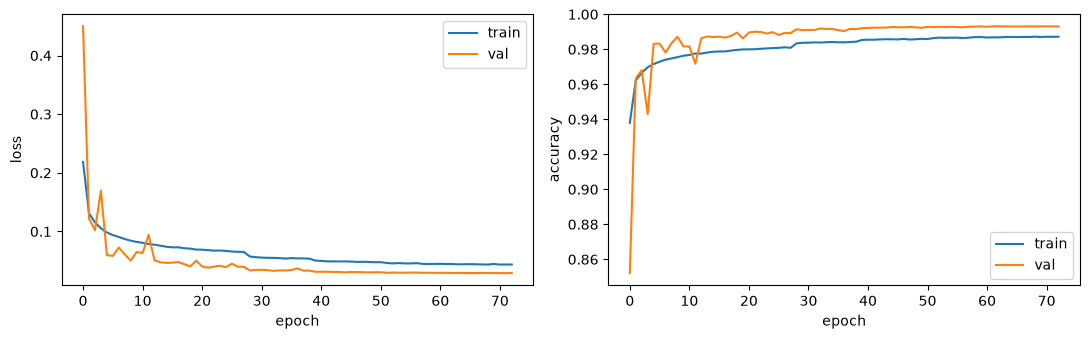

In [31]:
# --- Training ---------------------------------------------------------------------
# The whole split sits on DEVICE; each batch is just an index slice, so there is no
# per-batch host transfer. Val accuracy gates both ReduceLROnPlateau and early
# stopping, so training cuts off once the model stops improving rather than running
# all EPOCHS.
#
# Rerunning this cell continues training the model as it stands. Rerun the classifier
# cell first for a fresh start, otherwise the optimiser state and weights carry over.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

BATCH_SIZE = 64
LR_DECAY = 0.5          # multiply lr when val accuracy stalls
LR_PATIENCE = 5          # epochs without improvement before decay
EARLY_STOP = 10          # epochs without improvement before stopping
EPOCHS = 200
MLP_CKPT = Path("mlp_best.pt")  # weights from the best val epoch, rewritten as it improves

assert len(X_train) == len(train_y) and len(X_val) == len(val_y), "rerun the cells above"
assert model[0].in_features == X_train.shape[1], "model predates the current vectors"

X_tr = torch.from_numpy(X_train).to(DEVICE)
y_tr = torch.from_numpy(train_y).to(DEVICE)
X_va = torch.from_numpy(X_val).to(DEVICE)
y_va = torch.from_numpy(val_y).to(DEVICE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=LR_DECAY, patience=LR_PATIENCE)


def run_epoch(X, y, train):
    """One pass over rows already on DEVICE -> mean loss, accuracy."""
    model.train(train)
    n = len(y)
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)
    if train:                                   # BatchNorm needs more than one row
        order = order[: (n // BATCH_SIZE) * BATCH_SIZE]
    loss_sum = correct = seen = 0.0
    with torch.set_grad_enabled(train):
        for start in range(0, len(order), BATCH_SIZE):
            idx = order[start:start + BATCH_SIZE]
            logits = model(X[idx])
            loss = criterion(logits, y[idx])
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            bs = len(idx)
            loss_sum += loss.detach() * bs
            correct += (logits.argmax(1) == y[idx]).sum()
            seen += bs
    return (loss_sum / seen).item(), (correct / seen).item()


history, best_acc, stale = [], 0.0, 0
for epoch in tqdm(range(1, EPOCHS + 1), desc="train", unit="ep"):
    tr_loss, tr_acc = run_epoch(X_tr, y_tr, True)
    va_loss, va_acc = run_epoch(X_va, y_va, False)
    history.append((tr_loss, tr_acc, va_loss, va_acc))
    scheduler.step(va_acc)
    if va_acc > best_acc:
        best_acc, stale = va_acc, 0
        torch.save(model.state_dict(), MLP_CKPT)
    else:
        stale += 1
    if epoch == 1 or epoch % 5 == 0 or stale == 0:
        lr = optimizer.param_groups[0]["lr"]
        print(f"{epoch:3d}  train {tr_loss:.4f} / {tr_acc:6.2%}   "
              f"val {va_loss:.4f} / {va_acc:6.2%}   lr {lr:.2e}")
    if stale >= EARLY_STOP:
        print(f"early stop at epoch {epoch} ({EARLY_STOP} epochs without val improvement)")
        break

model.load_state_dict(torch.load(MLP_CKPT, map_location=DEVICE))
print(f"\nbest val accuracy {best_acc:.2%}, weights restored from {MLP_CKPT}")

hist = np.array(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col, name in zip(axes, (0, 1), ("loss", "accuracy")):
    ax.plot(hist[:, col], label="train")
    ax.plot(hist[:, col + 2], label="val")
    ax.set_xlabel("epoch")
    ax.set_ylabel(name)
    ax.legend()
plt.tight_layout()

6,576 labelled -> 6,526 past the palm gate -> 6,215 scored

test accuracy 76.07%   left 75.24% (3,102)   right 76.90% (3,113)
raw score says left on 50.2% of frames, folder says 49.9%, agreeing on 98.04%
weakest letters: Z 16%  K 35%  X 47%  I 49%  P 52%  T 55%  S 65%  D 66%
saved -> runs/3d+dir.npz


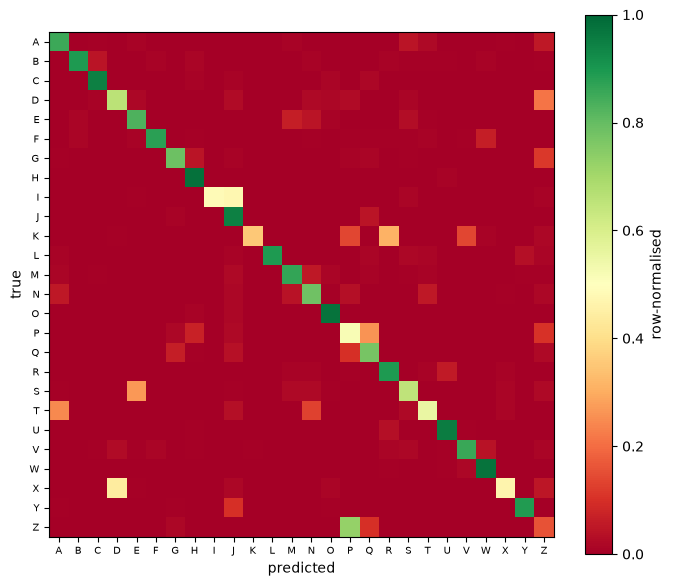

In [32]:
# --- Test: a separate capture, left/<LETTER> and right/<LETTER> -------------------
# Every step is the one train and val went through, reused rather than restated: the
# same presence and handedness gates, the same mirror, the same spans. A test number
# is only meaningful if it was produced the same way.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

RUNS_DIR = Path("runs")         # one <FEATURES>.npz per mode, read by experiments.ipynb

keep = keep_of(test_presence, test_handed)
test_y = test_labels[keep]
k, world, deg = mirror(test_kp[keep], test_world[keep], test_deg[keep],
                       test_handed[keep])
world -= world[:, :1, :]
# Clipped because the train+val spans were not measured on this capture, so a test
# frame can sit outside them; train and val are inside by construction and unaffected.
X_test = np.clip(features(k, world, deg), 0.0, 1.0)

model.eval()
with torch.no_grad():
    pred = model(torch.from_numpy(X_test).to(DEVICE)).argmax(1).cpu().numpy()

hit = pred == test_y
left = test_left[keep]
print(f"{test_labelled:,} labelled -> {test_detected:,} past the palm gate -> "
      f"{len(X_test):,} scored")
print(f"\ntest accuracy {hit.mean():.2%}   "
      f"left {hit[left].mean():.2%} ({left.sum():,})   "
      f"right {hit[~left].mean():.2%} ({(~left).sum():,})")

# Audit the mirror: the folder knows which hand it filmed, the raw score guesses.
print(f"raw score says left on {(test_handed[keep] < 0.5).mean():.1%} of frames, folder says "
      f"{left.mean():.1%}, agreeing on {((test_handed[keep] < 0.5) == left).mean():.2%}")

per_class = np.array([hit[test_y == i].mean() if (test_y == i).any() else np.nan
                      for i in range(len(CLASSES))])
worst = np.argsort(np.nan_to_num(per_class, nan=2.0))[:8]
print("weakest letters: " + "  ".join(f"{CLASSES[i]} {per_class[i]:.0%}" for i in worst))

cm = np.zeros((len(CLASSES), len(CLASSES)), int)
np.add.at(cm, (test_y, pred), 1)
plt.figure(figsize=(7, 6))
plt.imshow(cm / np.maximum(cm.sum(1, keepdims=True), 1), cmap="RdYlGn", vmin=0, vmax=1)
plt.xticks(range(len(CLASSES)), CLASSES, fontsize=7)
plt.yticks(range(len(CLASSES)), CLASSES, fontsize=7)
plt.xlabel("predicted")
plt.ylabel("true")
plt.colorbar(label="row-normalised")
plt.tight_layout()

# Everything experiments.ipynb needs to draw this run, one file per feature mode.
RUNS_DIR.mkdir(exist_ok=True)
np.savez(RUNS_DIR / f"{FEATURES}.npz",
         features=FEATURES, dims=IN_DIM, hidden=np.array(HIDDEN), dropout=DROPOUT,
         lr=LR, batch_size=BATCH_SIZE, history=hist, best_val=best_acc,
         y_true=np.array(CLASSES)[test_y], y_pred=np.array(CLASSES)[pred])
print(f"saved -> {RUNS_DIR / f'{FEATURES}.npz'}")